# Previsão de salários da NBA utilizando Deep Learning


Modelo de Deep Learning (ANN) para prever salários de jogadores da NBA (2017–2025) usando métricas de desempenho. O objetivo é investigar se é possível precificar um jogador exclusivamente por suas estatísticas.


## Importação e exploração dos dados


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset/NBA Player Stats and Salaries (2010-2025).csv")
df

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Kobe Bryant,23034375,2010,SG,31,LAL,73,73,38.8,9.8,...,0.811,1.1,4.3,5.4,5.0,1.5,0.3,3.2,2.6,27.0
1,Jermaine O'Neal,23016000,2010,C,31,MIA,70,70,28.4,5.6,...,0.720,1.8,5.2,6.9,1.3,0.4,1.4,1.8,3.0,13.6
2,Tracy McGrady,22843124,2010,SG,30,NYK,30,24,22.4,3.0,...,0.746,0.7,2.4,3.1,3.3,0.5,0.5,1.5,1.3,8.2
3,Tim Duncan,22183220,2010,C,33,SAS,78,77,31.3,7.2,...,0.725,2.8,7.3,10.1,3.2,0.6,1.5,1.8,1.9,17.9
4,Shaquille O'Neal,21000000,2010,C,37,CLE,53,53,23.4,4.9,...,0.496,1.8,4.9,6.7,1.5,0.3,1.2,2.0,3.2,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7293,Isaiah Mobley,11997,2025,PF,25,PHI,1,0,17.0,2.0,...,0.500,1.0,3.0,4.0,5.0,1.0,1.0,0.0,3.0,6.0
7294,Braxton Key,11997,2025,SF,27,GSW,3,0,3.7,0.0,...,0.500,0.3,0.3,0.7,0.0,0.7,0.0,0.3,0.0,1.0
7295,JD Davison,11997,2025,PG,22,BOS,16,0,5.8,0.8,...,0.714,0.1,0.7,0.8,0.8,0.3,0.1,0.8,0.1,2.1
7296,Kylor Kelley,73153,2025,C,27,NOP,11,2,11.5,1.3,...,0.600,1.1,2.5,3.5,0.5,0.1,0.3,0.4,1.4,3.1


> _Fonte: [Kaggle](https://www.kaggle.com/datasets/ratin21/nba-player-stats-and-salaries-2010-2025)_


Atributos do dataset:

| Atributo   | Significado               | Categoria |
| :--------- | :------------------------ | :-------- |
| **Player** | Nome                      | Cadastral |
| **Salary** | Salário                   | Cadastral |
| **Year**   | Ano (temporada)           | Cadastral |
| **Pos**    | Posição                   | Cadastral |
| **Age**    | Idade                     | Cadastral |
| **Team**   | Time                      | Cadastral |
| **G**      | Jogos                     | Total     |
| **GS**     | Jogos como titular        | Total     |
| **MP**     | Minutos por jogo          | Média     |
| **FG**     | Arremessos convertidos    | Média     |
| **FGA**    | Arremessos tentados       | Média     |
| **FG%**    | % acerto em arremessos    | Taxa      |
| **3P**     | 3pts convertidos          | Média     |
| **3PA**    | 3pts tentados             | Média     |
| **3P%**    | % acerto em 3pts          | Taxa      |
| **2P**     | 2pts convertidos          | Média     |
| **2PA**    | 2pts tentados             | Média     |
| **2P%**    | % acerto em 2pts          | Taxa      |
| **eFG%**   | % efetiva de arremessos   | Taxa      |
| **FT**     | Lances livres convertidos | Média     |
| **FTA**    | Lances livres tentados    | Média     |
| **FT%**    | % acerto em LL            | Taxa      |
| **ORB**    | Rebotes ofensivos         | Média     |
| **DRB**    | Rebotes defensivos        | Média     |
| **TRB**    | Total rebotes             | Média     |
| **AST**    | Assistências              | Média     |
| **STL**    | Roubos                    | Média     |
| **BLK**    | Tocos                     | Média     |
| **TOV**    | Perdas de bola            | Média     |
| **PF**     | Faltas                    | Média     |
| **PTS**    | Pontos                    | Média     |


Filtraremos apenas dados a partir de 2017, considerando as mudanças de paradigma (salto do teto salarial e revolução dos 3pts) que tornam temporadas anteriores incomparáveis.


In [3]:
df = df[df["Year"] >= 2017].reset_index(drop=True)
df

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,LeBron James,30963450,2017,SF,32,CLE,74,74,37.8,9.9,...,0.674,1.3,7.3,8.6,8.7,1.2,0.6,4.1,1.8,26.4
1,Mike Conley,26540100,2017,PG,29,MEM,69,68,33.2,6.7,...,0.859,0.4,3.0,3.5,6.3,1.3,0.3,2.3,1.8,20.5
2,DeMar DeRozan,26540100,2017,SG,27,TOR,74,74,35.4,9.7,...,0.842,0.9,4.3,5.2,3.9,1.1,0.2,2.4,1.8,27.3
3,Al Horford,26540100,2017,C,30,BOS,68,68,32.3,5.6,...,0.800,1.4,5.4,6.8,5.0,0.8,1.3,1.7,2.0,14.0
4,Kevin Durant,26540100,2017,PF,28,GSW,62,62,33.4,8.9,...,0.875,0.6,7.6,8.3,4.8,1.1,1.6,2.2,1.9,25.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,Isaiah Mobley,11997,2025,PF,25,PHI,1,0,17.0,2.0,...,0.500,1.0,3.0,4.0,5.0,1.0,1.0,0.0,3.0,6.0
4221,Braxton Key,11997,2025,SF,27,GSW,3,0,3.7,0.0,...,0.500,0.3,0.3,0.7,0.0,0.7,0.0,0.3,0.0,1.0
4222,JD Davison,11997,2025,PG,22,BOS,16,0,5.8,0.8,...,0.714,0.1,0.7,0.8,0.8,0.3,0.1,0.8,0.1,2.1
4223,Kylor Kelley,73153,2025,C,27,NOP,11,2,11.5,1.3,...,0.600,1.1,2.5,3.5,0.5,0.1,0.3,0.4,1.4,3.1


### Análise de correlação


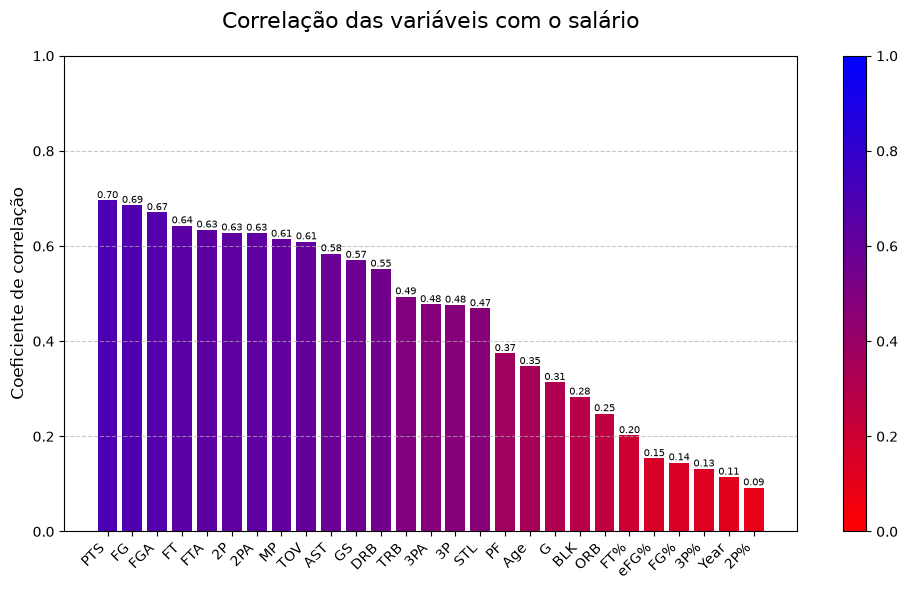

In [4]:
import matplotlib.colors as mcolors

numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
    df[numeric_columns].corr()["Salary"].drop("Salary").sort_values(ascending=False)
)

cmap = mcolors.LinearSegmentedColormap.from_list("RedBlue", ["red", "blue"])
norm = mcolors.Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    correlations.index, correlations.values, color=cmap(norm(correlations.values))
)

ax.set_title("Correlação das variáveis com o salário", fontsize=16, pad=20)
ax.set_ylabel("Coeficiente de correlação", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Salary** tem alta correlação com métricas de volume (PTS, MP, AST). TOV também aparece correlacionado, mas isso reflete tempo de quadra. eFG% e Age têm correlação baixa: não significa que são irrelevantes, apenas que não explicam o salário de forma linear.


### Distribuição dos salários


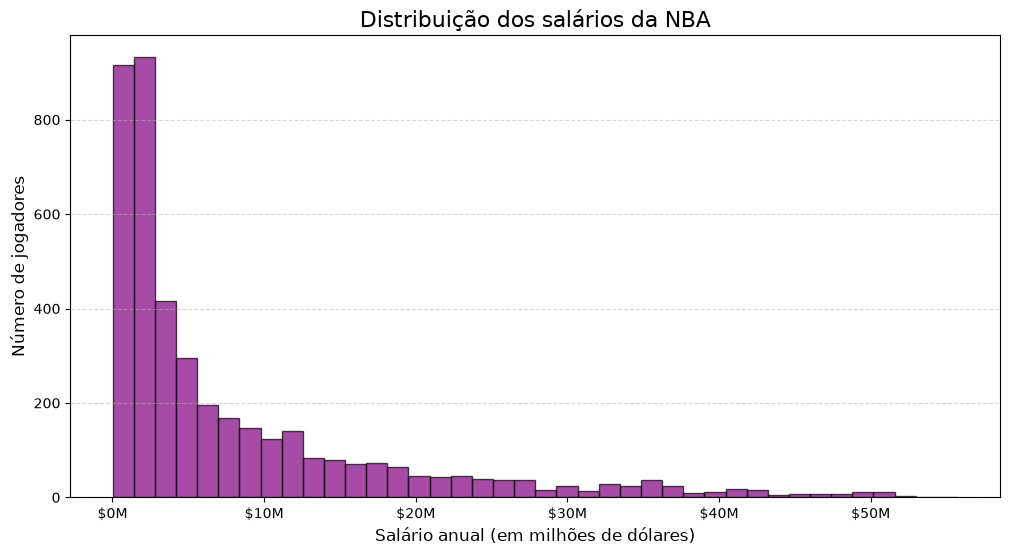

In [5]:
from matplotlib.ticker import FuncFormatter


def format_millions(x, pos):
    return f"${x / 1_000_000:.0f}M"


plt.figure(figsize=(12, 6))
plt.hist(df["Salary"], bins=40, color="purple", edgecolor="black", alpha=0.7)

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(format_millions))

plt.title("Distribuição dos salários da NBA", fontsize=16)
plt.xlabel("Salário anual (em milhões de dólares)", fontsize=12)
plt.ylabel("Número de jogadores", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Alta concentração de salários até ~$10M; super salários são fração minúscula da liga.


### Distribuição dos demais atributos numéricos


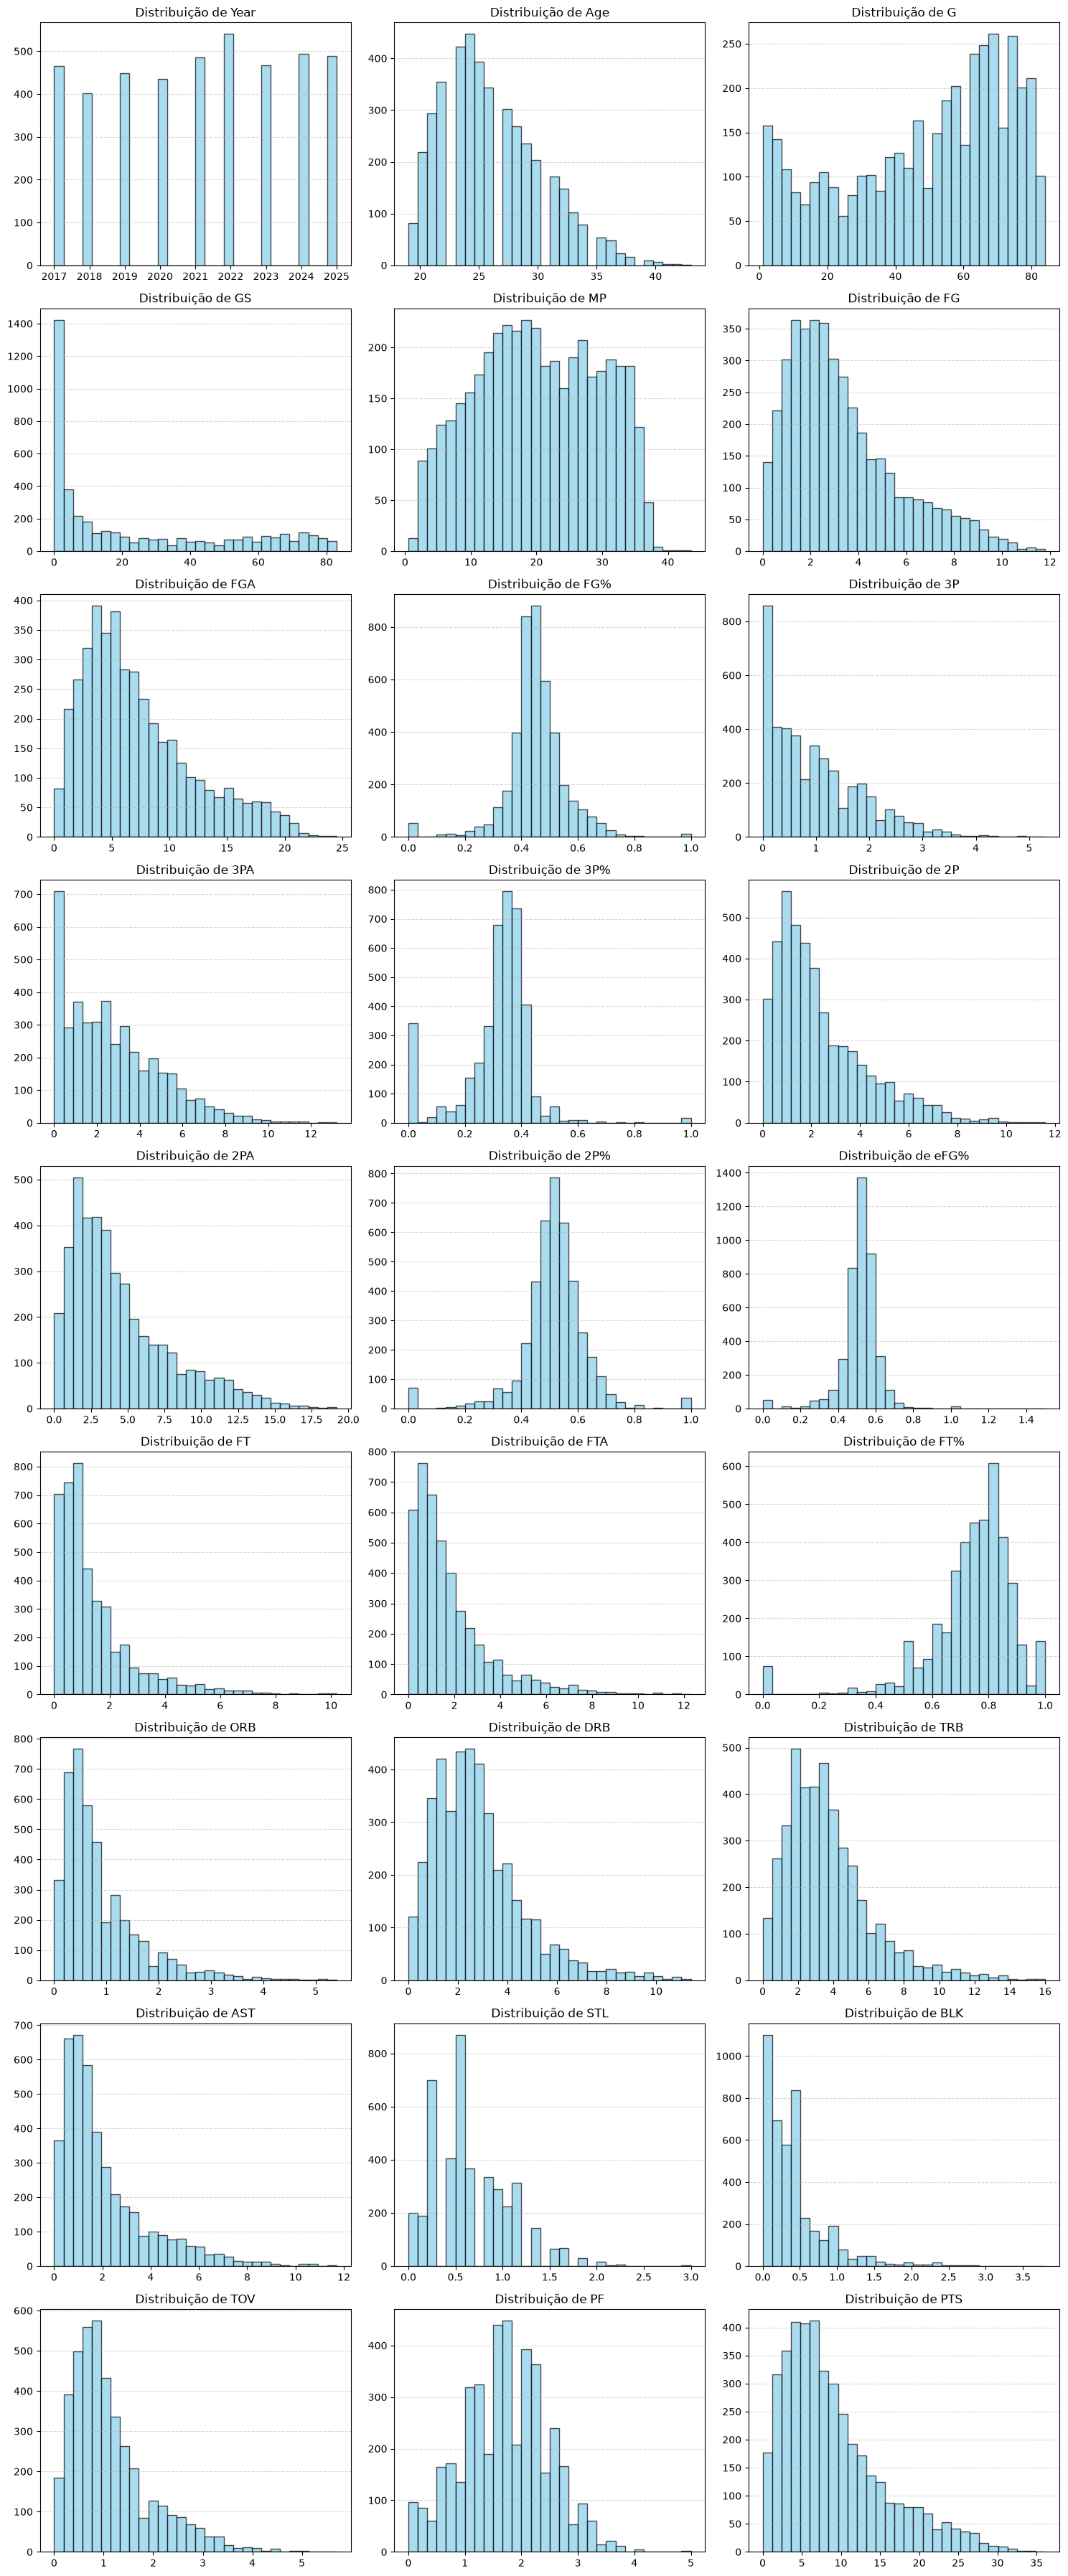

In [6]:
from math import ceil

columns_to_plot = [c for c in numeric_columns if c != "Salary"]
n_features = len(columns_to_plot)
n_cols = 3
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    axes[i].hist(
        df[col].dropna(), bins=30, color="skyblue", edgecolor="black", alpha=0.7
    )
    axes[i].set_title(f"Distribuição de {col}", fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

for i in range(i + 1, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Pré-processamento dos dados


Remoção de colunas redundantes ou de identificação:

- **Player** e **Team**: identificação (ruído)
- **ORB**, **DRB**, **FG**, **FGA**, **3P**, **3PA**, **2P**, **2PA**, **FT** e **FTA**: redundantes (derivam de outras colunas)
- **FG%** e **2P%**: redundantes (já existe **eFG%**)


In [7]:
columns_to_remove = [
    "Player",
    "Team",
    "ORB",
    "DRB",
    "FG",
    "FGA",
    "3P",
    "3PA",
    "2P",
    "2PA",
    "FT",
    "FTA",
    "FG%",
    "2P%",
]
df = df.drop(columns=columns_to_remove)
df

,Salary,Year,Pos,Age,G,GS,MP,3P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS
0,30963450,2017,SF,32,74,74,37.8,0.363,0.594,0.674,8.6,8.7,1.2,0.6,4.1,1.8,26.4
1,26540100,2017,PG,29,69,68,33.2,0.408,0.545,0.859,3.5,6.3,1.3,0.3,2.3,1.8,20.5
2,26540100,2017,SG,27,74,74,35.4,0.266,0.477,0.842,5.2,3.9,1.1,0.2,2.4,1.8,27.3
3,26540100,2017,C,30,68,68,32.3,0.355,0.527,0.800,6.8,5.0,0.8,1.3,1.7,2.0,14.0
4,26540100,2017,PF,28,62,62,33.4,0.375,0.594,0.875,8.3,4.8,1.1,1.6,2.2,1.9,25.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,11997,2025,PF,25,1,0,17.0,0.333,0.357,0.500,4.0,5.0,1.0,1.0,0.0,3.0,6.0
4221,11997,2025,SF,27,3,0,3.7,0.000,0.000,0.500,0.7,0.0,0.7,0.0,0.3,0.0,1.0
4222,11997,2025,PG,22,16,0,5.8,0.222,0.412,0.714,0.8,0.8,0.3,0.1,0.8,0.1,2.1
4223,73153,2025,C,27,11,2,11.5,NaN,0.636,0.600,3.5,0.5,0.1,0.3,0.4,1.4,3.1


Restam 17 colunas: **Salary, Year, Pos, Age, G, GS, MP, 3P%, eFG%, FT%, TRB, AST, STL, BLK, TOV, PF, PTS**.


### Tratamento de valores nulos

Apenas **3P%**, **eFG%** e **FT%** possuem nulos (jogadores que não tentaram o arremesso). Preenchemos com 0.


In [8]:
df.isnull().sum()

Salary      0
Year        0
Pos         0
Age         0
G           0
GS          0
MP          0
3P%       182
eFG%       13
FT%       127
TRB         0
AST         0
STL         0
BLK         0
TOV         0
PF          0
PTS         0
dtype: int64

In [9]:
percentage_columns = ["3P%", "FT%", "eFG%"]
df[percentage_columns] = df[percentage_columns].fillna(0)
df

,Salary,Year,Pos,Age,G,GS,MP,3P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS
0,30963450,2017,SF,32,74,74,37.8,0.363,0.594,0.674,8.6,8.7,1.2,0.6,4.1,1.8,26.4
1,26540100,2017,PG,29,69,68,33.2,0.408,0.545,0.859,3.5,6.3,1.3,0.3,2.3,1.8,20.5
2,26540100,2017,SG,27,74,74,35.4,0.266,0.477,0.842,5.2,3.9,1.1,0.2,2.4,1.8,27.3
3,26540100,2017,C,30,68,68,32.3,0.355,0.527,0.800,6.8,5.0,0.8,1.3,1.7,2.0,14.0
4,26540100,2017,PF,28,62,62,33.4,0.375,0.594,0.875,8.3,4.8,1.1,1.6,2.2,1.9,25.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4220,11997,2025,PF,25,1,0,17.0,0.333,0.357,0.500,4.0,5.0,1.0,1.0,0.0,3.0,6.0
4221,11997,2025,SF,27,3,0,3.7,0.000,0.000,0.500,0.7,0.0,0.7,0.0,0.3,0.0,1.0
4222,11997,2025,PG,22,16,0,5.8,0.222,0.412,0.714,0.8,0.8,0.3,0.1,0.8,0.1,2.1
4223,73153,2025,C,27,11,2,11.5,0.000,0.636,0.600,3.5,0.5,0.1,0.3,0.4,1.4,3.1


### Filtragem de outliers

Jogadores com poucos jogos poluem o dataset. Mantemos apenas quem jogou 10+ partidas e 5+ min/jogo.


In [10]:
df = df[(df["G"] >= 10) & (df["MP"] >= 5)].reset_index(drop=True)
df

,Salary,Year,Pos,Age,G,GS,MP,3P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS
0,30963450,2017,SF,32,74,74,37.8,0.363,0.594,0.674,8.6,8.7,1.2,0.6,4.1,1.8,26.4
1,26540100,2017,PG,29,69,68,33.2,0.408,0.545,0.859,3.5,6.3,1.3,0.3,2.3,1.8,20.5
2,26540100,2017,SG,27,74,74,35.4,0.266,0.477,0.842,5.2,3.9,1.1,0.2,2.4,1.8,27.3
3,26540100,2017,C,30,68,68,32.3,0.355,0.527,0.800,6.8,5.0,0.8,1.3,1.7,2.0,14.0
4,26540100,2017,PF,28,62,62,33.4,0.375,0.594,0.875,8.3,4.8,1.1,1.6,2.2,1.9,25.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3721,126356,2025,SF,23,10,4,25.3,0.156,0.428,0.800,7.0,1.0,0.9,1.2,0.7,1.6,6.7
3722,47989,2025,PG,25,33,3,14.8,0.400,0.585,0.833,1.8,2.3,0.7,0.2,1.2,1.0,8.3
3723,789048,2025,PG,30,24,9,21.3,0.167,0.332,0.571,3.3,6.9,1.0,0.5,2.5,1.5,3.5
3724,11997,2025,PG,22,16,0,5.8,0.222,0.412,0.714,0.8,0.8,0.3,0.1,0.8,0.1,2.1


### Posições compostas

Alguns jogadores têm duas posições (ex: "SF-PF"). Mantemos apenas a primeira.


In [11]:
df["Pos"] = df["Pos"].str.split("-").str[0]
print("Positions:", df["Pos"].unique())

Positions: ['SF' 'PG' 'SG' 'C' 'PF']


### Normalização salarial pelo teto

A diferença do teto salarial entre 2017 e 2025 é de ~$47M. Para o modelo ser preciso, convertemos salários para porcentagem do teto de cada temporada.


In [12]:
salary_cap = {
    2017: 94_143_000,
    2018: 99_093_000,
    2019: 101_869_000,
    2020: 109_140_000,
    2021: 109_140_000,
    2022: 112_414_000,
    2023: 123_655_000,
    2024: 136_021_000,
    2025: 140_588_000,
}

df["Cap"] = df["Year"].map(salary_cap)
df["Salary%"] = df["Salary"] / df["Cap"]
df = df.drop(columns=["Salary", "Cap"])
df

,Year,Pos,Age,G,GS,MP,3P%,eFG%,FT%,TRB,AST,STL,BLK,TOV,PF,PTS,Salary%
0,2017,SF,32,74,74,37.8,0.363,0.594,0.674,8.6,8.7,1.2,0.6,4.1,1.8,26.4,0.328898
1,2017,PG,29,69,68,33.2,0.408,0.545,0.859,3.5,6.3,1.3,0.3,2.3,1.8,20.5,0.281913
2,2017,SG,27,74,74,35.4,0.266,0.477,0.842,5.2,3.9,1.1,0.2,2.4,1.8,27.3,0.281913
3,2017,C,30,68,68,32.3,0.355,0.527,0.800,6.8,5.0,0.8,1.3,1.7,2.0,14.0,0.281913
4,2017,PF,28,62,62,33.4,0.375,0.594,0.875,8.3,4.8,1.1,1.6,2.2,1.9,25.1,0.281913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3721,2025,SF,23,10,4,25.3,0.156,0.428,0.800,7.0,1.0,0.9,1.2,0.7,1.6,6.7,0.000899
3722,2025,PG,25,33,3,14.8,0.400,0.585,0.833,1.8,2.3,0.7,0.2,1.2,1.0,8.3,0.000341
3723,2025,PG,30,24,9,21.3,0.167,0.332,0.571,3.3,6.9,1.0,0.5,2.5,1.5,3.5,0.005612
3724,2025,PG,22,16,0,5.8,0.222,0.412,0.714,0.8,0.8,0.3,0.1,0.8,0.1,2.1,0.000085


> _Fonte: [Basketball Reference](https://www.basketball-reference.com/contracts/salary-cap-history.html)_


### Codificação e normalização

Atributos contínuos serão padronizados (StandardScaler) e a posição (categórica) será one-hot encoded.


In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = [
    "Age",
    "G",
    "GS",
    "MP",
    "3P%",
    "eFG%",
    "FT%",
    "TRB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "PF",
    "PTS",
]
categorical_features = ["Pos"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="passthrough",
)

### Separação treino/validação/teste

- Treino: 2017–2022 (66%)
- Validação: 2023–2024 (22%)
- Teste: 2025 (12%)

A coluna **Year** foi removida dos atributos; como o salário já foi normalizado pelo teto, o ano se tornou redundante.


In [14]:
train = df[df["Year"] <= 2022].copy()
val = df[df["Year"].between(2023, 2024)].copy()
test = df[df["Year"] == 2025].copy()

X_train = train.drop(columns=["Salary%", "Year"])
y_train = train["Salary%"]
X_val = val.drop(columns=["Salary%", "Year"])
y_val = val["Salary%"]
X_test = test.drop(columns=["Salary%", "Year"])
y_test = test["Salary%"]

### Transformação logarítmica do alvo

Os histogramas mostraram caudas longas. Aplicamos log para melhor distribuição.


In [15]:
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)
y_test = np.log1p(y_test)

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

## Modelagem e compilação do modelo


Rede Neural Artificial (ANN) com 4 camadas ocultas densas e saída sigmoid (regressão).


In [17]:
from keras import Input, layers, Model

inputs = Input(shape=(X_train_processed.shape[1],))
x = layers.Dense(128, activation="relu")(inputs)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(8, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

I0000 00:00:1783201515.555271  111860 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,169 (51.44 KB)

 Trainable params: 13,169 (51.44 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer="sgd", loss="mse", metrics=["mae"])

## Treinamento validativo

Primeiro treinamento para verificar se o modelo está ajustado. Usa EarlyStopping para evitar overfitting.


In [19]:
final_training = True
n_epochs = 200
batch_size = 16

In [20]:
from keras.callbacks import EarlyStopping

if not final_training:
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )

    report = model.fit(
        x=X_train_processed,
        y=y_train,
        validation_data=[X_val_processed, y_val],
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
    )

    loss = report.history["loss"]
    mae = report.history["mae"]
    val_loss = report.history["val_loss"]
    val_mae = report.history["val_mae"]

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    ax[0].plot(epochs, loss, label="MSE")
    ax[0].plot(epochs, val_loss, label="val-MSE")
    ax[1].plot(epochs, mae, label="MAE")
    ax[1].plot(epochs, val_mae, label="val-MAE")

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].legend()
        ax[i].grid()

    plt.show()

## Treinamento final

Treina com treino + validação combinados, sem early stopping.


Epoch 1/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0552 - mae: 0.2101
Epoch 2/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0091 - mae: 0.0816
Epoch 3/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0055 - mae: 0.0593
Epoch 4/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045 - mae: 0.0513
Epoch 5/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0471
Epoch 6/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0035 - mae: 0.0442
Epoch 7/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0032 - mae: 0.0420
Epoch 8/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0030 - mae: 0.0405
Epoch 9/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0029 - mae: 0.0391
Epoch 10/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0028 - mae: 0.0381
Epoch 11/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0027 - mae: 0.0372
Epoch 12/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0026 - mae: 0.0366
Epoch 13/200


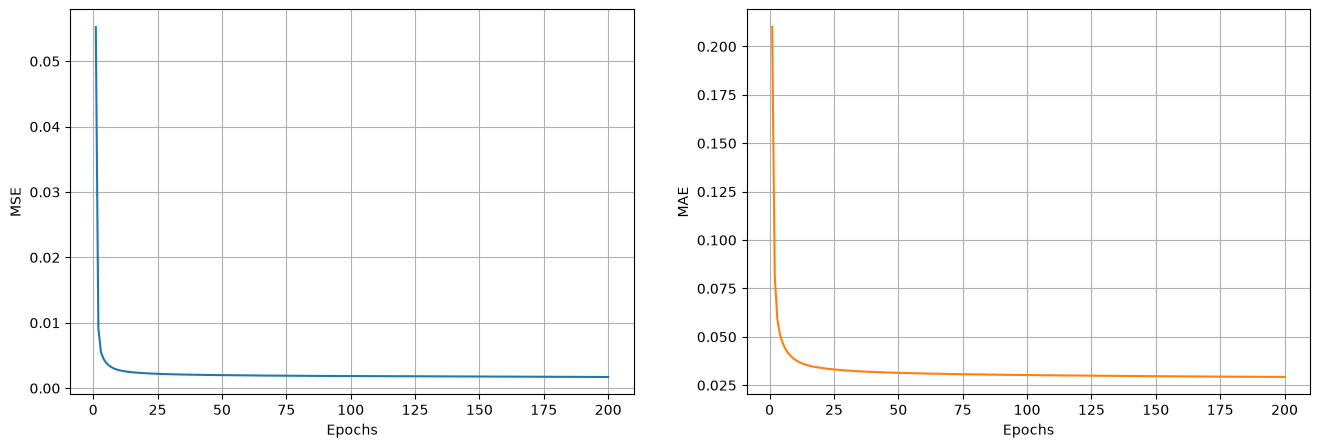

In [21]:
if final_training:
    report = model.fit(
        x=np.concatenate([X_train_processed, X_val_processed]),
        y=np.concatenate([y_train, y_val]),
        epochs=n_epochs,
        batch_size=batch_size,
    )

    loss = report.history["loss"]
    mae = report.history["mae"]

    epochs = np.linspace(1, len(loss), len(loss))

    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    ax[0].plot(epochs, loss, c="tab:blue")
    ax[1].plot(epochs, mae, c="tab:orange")
    ax[0].set_ylabel("MSE")
    ax[1].set_ylabel("MAE")

    for i in range(2):
        ax[i].set_xlabel("Epochs")
        ax[i].grid()

    plt.show()

## Avaliação do modelo


In [22]:
if final_training:
    mse, mae = model.evaluate(x=X_test_processed, y=y_test, batch_size=batch_size)
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - mae: 0.0306  
MSE: 0.0018
MAE: 0.0306


Resultado: MSE = 0,0018 e MAE = 3,06% na escala logarítmica.


In [23]:
if final_training:
    y_pred = model.predict(X_test_processed)
    y_pred = np.expm1(y_pred)

    test_year = 2025
    test_salary_cap = salary_cap[test_year]

    print("y_pred     |     y_test")
    print("-----------------------")
    for p, y in zip(y_pred, y_test):
        pred_salary = p[0] * test_salary_cap
        test_salary = y * test_salary_cap
        print(f"{pred_salary:,.0f} | {test_salary:,.0f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
y_pred     |     y_test
-----------------------
51,118,008 | 46,964,990
46,556,136 | 43,818,785
45,186,564 | 43,818,785
56,324,204 | 43,645,204
33,217,948 | 42,928,523
39,400,368 | 42,191,104
31,647,114 | 42,191,104
34,656,580 | 42,191,104
44,834,248 | 42,191,104
48,440,100 | 42,191,104
39,097,572 | 41,889,208
50,655,932 | 41,881,041
56,584,632 | 41,881,041
57,550,456 | 41,837,360
33,358,624 | 38,685,644
31,055,398 | 38,149,707
53,909,204 | 37,685,325
29,333,950 | 37,541,839
17,827,000 | 37,541,839
26,507,876 | 37,399,874
22,257,732 | 36,885,267
11,246,876 | 36,885,267
31,684,632 | 36,885,267
35,479,244 | 36,885,267
54,605,068 | 35,977,419
24,456,820 | 35,589,778
31,358,264 | 32,628,603
26,867,142 | 32,628,603
14,952,180 | 32,628,603
22,861,518 | 32,559,020
32,877,412 | 32,064,952
29,728,334 | 32,064,952
39,203,252 | 31,940,512
19,252,534 | 31,940,512
33,905,416 | 31,581,796
21,684,504 | 31,371,306
15,981,808 | 31,371,306
38,056,044 | 31,132,174


O modelo alcançou MAE de 3,06%, demonstrando alta capacidade de precificar jogadores. Discrepâncias ocorrem em casos especiais: quando a previsão é muito acima, o jogador pode estar subvalorizado (ex: calouros com salário fixo). Quando abaixo, pode ser um jogador lesionado ou com contrato máximo de anos anteriores. No geral, o modelo generaliza bem o comportamento da liga, isolando o rendimento real das distorções financeiras e regras de teto salarial.


## Salvando o modelo

Salvamos no formato `.keras` (arquitetura + pesos) e o pré-processador com joblib.


In [24]:
save_model = True

In [25]:
from joblib import dump

if save_model:
    model.save("artifacts/model.keras")
    dump(preprocessor, "artifacts/preprocessor.pkl")

## Aplicação do modelo em casos reais

Simulação de fluxo real: carrega o modelo salvo e testa em jogadores com dados que o modelo nunca viu.


In [26]:
load_model = True

In [27]:
from keras.models import load_model as keras_load_model
from joblib import load

if load_model:
    loaded_model = keras_load_model("artifacts/model.keras")
    loaded_preprocessor = load("artifacts/preprocessor.pkl")

Dados da temporada 2026 (teto: $154,647,000):

| Player                | Pos | Age | G   | GS  | MP   | 3P%   | eFG%  | FT%   | TRB  | AST | STL | BLK | TOV | PF  | PTS  | Salary      |
| :-------------------- | :-- | :-- | :-- | :-- | :--- | :---- | :---- | :---- | :--- | :-- | :-- | :-- | :-- | :-- | :--- | :---------- |
| Giannis Antetokounmpo | PF  | 31  | 36  | 36  | 28.9 | 0.333 | 0.636 | 0.650 | 9.8  | 5.4 | 0.9 | 0.7 | 3.2 | 2.4 | 27.6 | $54,126,450 |
| Victor Wembanyama     | C   | 22  | 64  | 55  | 29.2 | 0.349 | 0.569 | 0.827 | 11.5 | 3.1 | 1.0 | 3.1 | 2.4 | 2.4 | 25.0 | $13,376,880 |
| LeBron James          | SF  | 41  | 60  | 60  | 33.2 | 0.317 | 0.557 | 0.737 | 6.1  | 7.2 | 1.2 | 0.6 | 3.0 | 1.4 | 20.9 | $52,627,153 |

> _Fonte: Basketball Reference ([Estatísticas](https://www.basketball-reference.com/leagues/NBA_2026_per_game.html)) ([Salários](https://www.basketball-reference.com/contracts/players.html))_


In [28]:
if load_model:
    data = {
        "Player": ["Giannis Antetokounmpo", "Victor Wembanyama", "LeBron James"],
        "Pos": ["PF", "C", "SF"],
        "Age": [31, 22, 41],
        "G": [36, 64, 60],
        "GS": [36, 55, 60],
        "MP": [28.9, 29.2, 33.2],
        "3P%": [0.333, 0.349, 0.317],
        "eFG%": [0.636, 0.569, 0.557],
        "FT%": [0.650, 0.827, 0.737],
        "TRB": [9.8, 11.5, 6.1],
        "AST": [5.4, 3.1, 7.2],
        "STL": [0.9, 1.0, 1.2],
        "BLK": [0.7, 3.1, 0.6],
        "TOV": [3.2, 2.4, 3.0],
        "PF": [2.4, 2.4, 1.4],
        "PTS": [27.6, 25.0, 20.9],
        "Salary_Real": [54_126_450, 13_376_880, 52_627_153],
    }

    df_test = pd.DataFrame(data)

    X_new = df_test.drop(columns=["Player", "Salary_Real"])
    X_transformed = loaded_preprocessor.transform(X_new)

    log_pred = loaded_model.predict(X_transformed)
    salary_pcts = np.expm1(log_pred)

    salary_cap_2026 = 154_647_000
    predicted_salaries = salary_pcts * salary_cap_2026

    print("-" * 30)
    for i in range(len(df_test)):
        name = df_test["Player"][i]
        predicted = predicted_salaries[i][0]
        actual = df_test["Salary_Real"][i]
        error = predicted - actual

        print(f"Jogador: {name}")
        print(f"Predito: ${predicted:,.0f}")
        print(f"Atual  : ${actual:,.0f}")
        print(f"Erro   : {'+' if error > 0 else ''}${error:,.0f}")
        print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
------------------------------
Jogador: Giannis Antetokounmpo
Predito: $58,148,048
Atual  : $54,126,450
Erro   : +$4,021,598
------------------------------
Jogador: Victor Wembanyama
Predito: $19,000,652
Atual  : $13,376,880
Erro   : +$5,623,772
------------------------------
Jogador: LeBron James
Predito: $57,876,536
Atual  : $52,627,153
Erro   : +$5,249,383
------------------------------
